In [4]:
import pandas as pd 

data = pd.read_excel("Online Retail.xlsx")

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
import os 
print(os.getcwd())

C:\Users\moham


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
data_clean = data.dropna(subset = ['CustomerID'])

In [9]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [10]:
data_clean['Revenue'] = data_clean['Quantity'] * data_clean['UnitPrice']
data_clean[['Quantity', 'UnitPrice', 'Revenue']].head()

C:\Users\moham\AppData\Local\Temp\ipykernel_2352\1701494307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_clean['Revenue'] = data_clean['Quantity'] * data_clean['UnitPrice']


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [11]:
data_clean[data_clean['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [12]:
(data_clean['Quantity'] < 0).sum()

np.int64(8905)

In [13]:
data_clean['Revenue'].describe()

count    406829.000000
mean         20.401854
std         427.591718
min     -168469.600000
25%           4.200000
50%          11.100000
75%          19.500000
max      168469.600000
Name: Revenue, dtype: float64

In [18]:
data_clean[data_clean["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [19]:
data_clean["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(8905)

In [20]:
data_rfm = data_clean[data_clean["Quantity"] > 0].copy()

In [22]:
data_rfm = data_clean["Revenue"] = data_rfm["Quantity"] * data_rfm["UnitPrice"]

C:\Users\moham\AppData\Local\Temp\ipykernel_2352\169933663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_rfm = data_clean["Revenue"] = data_rfm["Quantity"] * data_rfm["UnitPrice"]


In [23]:
data_rfm = data_clean[data_clean["Quantity"] > 0].copy()

In [24]:
data_rfm.shape

(397924, 9)

In [25]:
data_rfm["Revenue"] = (
    data_rfm["Quantity"] * data_rfm["UnitPrice"]
)

In [26]:
data_rfm["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [27]:
snapshot_date = pd.Timestamp("2011-12-10")

rfm = data_rfm.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,18,1,1757.55
12350.0,310,1,334.40


In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.041484,4.271952,2053.793018
std,100.007757,7.705493,8988.248381
min,0.000000,1.000000,0.000000
25%,17.000000,1.000000,307.245000
50%,50.000000,2.000000,674.450000
75%,141.500000,5.000000,1661.640000
max,373.000000,210.000000,280206.020000


In [30]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4339 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4339 non-null   int64  
 1   Frequency  4339 non-null   int64  
 2   Monetary   4339 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [36]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels = [5,4,3,2,1]
)

In [40]:
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method = "first"),
    5,
    labels = [1,2,3,4,5]
)

In [41]:
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels = [1,2,3,4,5]
)

In [42]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

In [43]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,,,
12346.0,325,1,77183.60,1,1,5,1,1,5,115
12347.0,2,7,4310.00,5,5,5,5,5,5,555
12348.0,75,4,1797.24,2,4,4,2,4,4,244
12349.0,18,1,1757.55,4,1,4,4,1,4,414
12350.0,310,1,334.40,1,1,2,1,1,2,112


In [44]:
rfm["RFM_Score"].value_counts().head(10)

RFM_Score
555    348
111    181
455    175
121    154
112    127
444    118
122     92
544     88
233     86
344     85
Name: count, dtype: int64

In [47]:
rfm = rfm.drop(columns = ["R_score", "F_score", "M_score"])

In [48]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,18,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


In [49]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'

    elif r>= 3 and f>= 4:
        return 'Loyal Customers'

    elif r >= 4 and f >= 2:
        return 'Potential Loyalists'

    elif r <= 2 and f>= 3:
        return 'At Risk'

    elif r <= 2 and f <= 2:
        return 'Lost Customers'

    else:
        return 'Other'

In [50]:
rfm['Segment'] = rfm.apply(segment_customer, axis = 1)

In [51]:
rfm['Segment'].value_counts()

Segment
Lost Customers         1071
Champions               953
Other                   676
At Risk                 656
Loyal Customers         499
Potential Loyalists     484
Name: count, dtype: int64

In [52]:
segment_percentage = (
    rfm["Segment"]
    .value_counts(normalize = True)
    .mul(100)
    .round(2)
)

segment_percentage

Segment
Lost Customers         24.68
Champions              21.96
Other                  15.58
At Risk                15.12
Loyal Customers        11.50
Potential Loyalists    11.15
Name: proportion, dtype: float64

In [53]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending = False)
)

segment_revenue

,count,sum,mean
Segment,,,
Champions,953,5770243.550,6054.820094
Loyal Customers,499,916648.551,1836.971044
At Risk,656,819287.251,1248.913492
Lost Customers,1071,523336.982,488.643307
Potential Loyalists,484,503951.450,1041.222004
Other,676,377940.120,559.083018


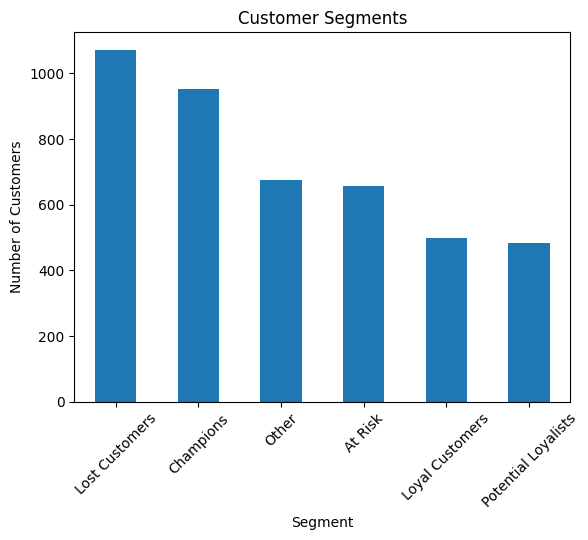

In [54]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind = "bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation = 45)

plt.show()

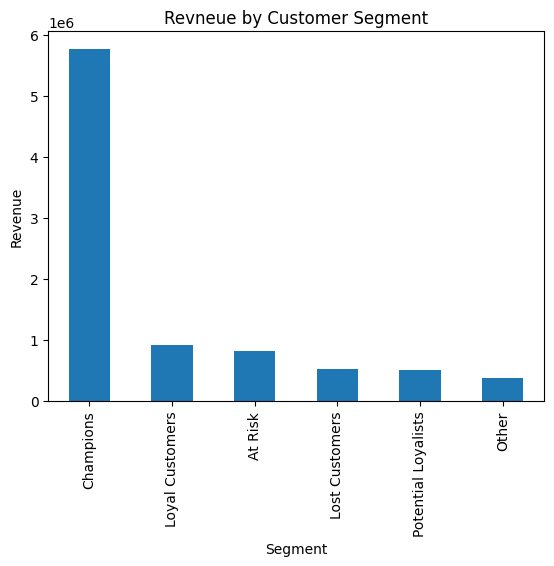

In [55]:
segment_revenue["sum"].plot(kind= "bar")

plt.title("Revneue by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue")

plt.show()

In [56]:
rfm.to_csv("rfm_customer_segments.csv")

2026-08-11 13:43:06.004 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 13:43:06.334 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 13:43:09.705 
  command:

    streamlit run C:\Users\moham\AppData\Local\Programs\Python\Python39\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-11 13:43:09.720 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 13:43:09.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 13:43:09.799 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-11 13:43:09.819 Thread 'MainThread': missing ScriptRunContext! This war

DeltaGenerator()

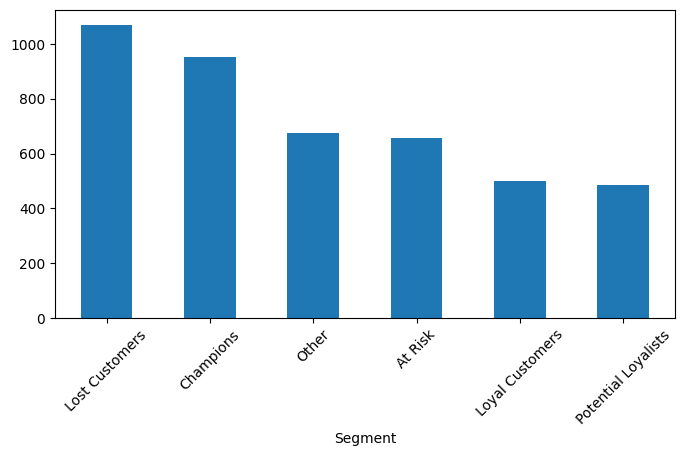

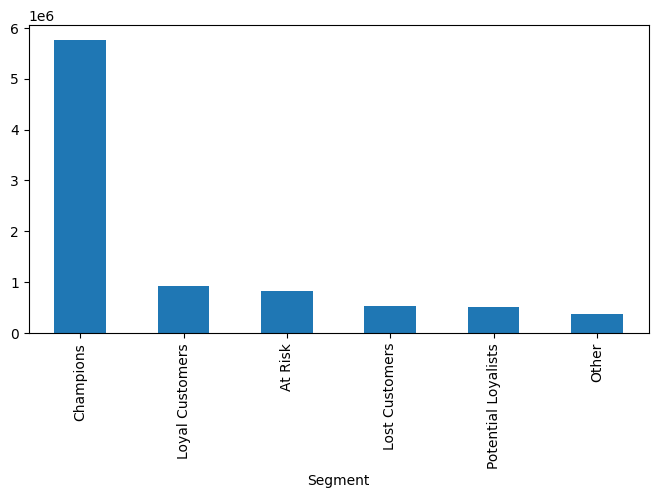

In [60]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Page Config
st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    page_icon="📊",
    layout="wide"
)

# Load Data
df = pd.read_csv("rfm_customer_segments.csv")

# Title
st.title("📊 Customer Segmentation Dashboard")
st.markdown("RFM Analysis of Retail Customers")

# KPIs
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric("Total Customers", len(df))

with col2:
    st.metric("Total Revenue", f"£{df['Monetary'].sum():,.0f}")

with col3:
    st.metric("Average Customer Value",
              f"£{df['Monetary'].mean():,.0f}")

with col4:
    champions = len(df[df["Segment"] == "Champions"])
    st.metric("Champions", champions)

# Segment Distribution
st.subheader("Customer Segment Distribution")

segment_counts = df["Segment"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
segment_counts.plot(kind="bar", ax=ax)
plt.xticks(rotation=45)

st.pyplot(fig)

# Revenue by Segment
st.subheader("Revenue by Segment")

segment_revenue = (
    df.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
segment_revenue.plot(kind="bar", ax=ax)

st.pyplot(fig)

# Filter
st.subheader("Customer Details")

segment_filter = st.selectbox(
    "Select Segment",
    ["All"] + sorted(df["Segment"].unique())
)

if segment_filter != "All":
    filtered_df = df[df["Segment"] == segment_filter]
else:
    filtered_df = df

st.dataframe(filtered_df)